In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
from pathlib import Path
import matplotlib.pyplot as plt
import squidpy as sq

/opt/conda/envs/perturb/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/conda/envs/perturb/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
def try_get_gene_names(codebook_dict, n_expected):
    # Heuristics for common field names in codebooks
    for k in ["GeneNames", "genes", "Targets", "targetNames", "Names", "name", "genes_list"]:
        if k in codebook_dict:
            arr = codebook_dict[k]
            # convert nested arrays/bytes to plain Python strings
            names = []
            for x in (arr.tolist() if hasattr(arr, "tolist") else arr):
                if isinstance(x, (bytes, bytearray)):
                    names.append(x.decode("utf-8", "ignore"))
                elif hasattr(x, "dtype") and str(x.dtype).startswith("<U"):
                    names.append(str(x))
                else:
                    names.append(str(x))
            if len(names) == n_expected:
                return names
    return [f"g{i}" for i in range(n_expected)]

def sniff_mat_version(path):
    """Return 'hdf5', 'mat5', or 'unknown' by sniffing the header."""
    with open(path, 'rb') as f:
        head = f.read(128)
    if head.startswith(b'\x89HDF'):   # HDF5 magic
        return 'hdf5'
    # MATLAB v5/v7 header contains ASCII text starting with 'MATLAB'
    if b'MATLAB' in head[:128]:
        return 'mat5'
    return 'unknown'

def load_mat(path):
    import numpy as np
    from scipy.io import loadmat

    def _todict(ms):
        d = {}
        for fld in ms._fieldnames:
            d[fld] = _convert(getattr(ms, fld))
        return d

    def _convert(x):
        from scipy.io.matlab import mat_struct
        import numpy as np
        if isinstance(x, mat_struct):
            return _todict(x)
        if isinstance(x, np.ndarray):
            if x.dtype == object:      # cell arrays / struct arrays
                return [ _convert(e) for e in x.reshape(-1) ]
            return x
        return x

    kind = sniff_mat_version(path)
    if kind == 'hdf5':
        # v7.3 path
        try:
            import mat73
            return mat73.loadmat(path)
        except Exception as e:
            raise RuntimeError(f"Detected v7.3 (HDF5) but failed to load via mat73: {e}")
    elif kind == 'mat5':
        # classic v5/v7 path
        data = loadmat(path, struct_as_record=False, squeeze_me=True)
        data = {k:v for k,v in data.items() if not k.startswith('__')}
        return {k:_convert(v) for k,v in data.items()}
    else:
        raise OSError("File does not look like a MATLAB .mat (neither v7.3/HDF5 nor v5/v7 header found).")

def mf_gene_names_from_codebook(codebook_mf, expected_len=None):
    """
    Return MERFISH gene names (ShortName preferred, fallback Header) in the
    SAME ORDER as the vector indices.
    """
    entries = codebook_mf.get("CodeBook", [])
    names = []
    for e in entries:
        nm = e.get("ShortName") or e.get("Header")
        if nm is None:
            raise ValueError("MERFISH codebook entry missing ShortName/Header.")
        names.append(str(nm))
    if expected_len is not None and len(names) != expected_len:
        print(f"[warn] MERFISH codebook length {len(names)} != MERFISH vector length {expected_len}. "
              "Assuming file order still matches vector order.")
    return names

def rf_target_names_from_codebook(codebook_rf, expected_len=None):
    """
    Return RaeFISH target labels (Target) in the SAME ORDER as the vector indices.
    """
    entries = codebook_rf.get("CodeBook", [])
    names = []
    for e in entries:
        nm = e.get("Target")
        if nm is None:
            raise ValueError("RaeFISH codebook entry missing Target.")
        names.append(str(nm))
    if expected_len is not None and len(names) != expected_len:
        print(f"[warn] RaeFISH codebook length {len(names)} != RaeFISH vector length {expected_len}. "
              "Assuming file order still matches vector order.")
    return names

def raefish_gene_from_vector(v: np.ndarray, names: list, ntc_label: str = "NTC"):
    """
    Map one RaeFISH count vector -> a single label.
      - sum == 0  -> NTC
      - exactly one positive -> that gene
      - else -> unique argmax; ties => 'Ambiguous'
    """
    s = int(np.asarray(v).sum())
    if s == 0:
        return ntc_label
    v = np.asarray(v)
    pos = np.flatnonzero(v > 0)
    if pos.size == 1:
        return names[pos[0]] if pos[0] < len(names) else "Unknown"
    m = v.max()
    winners = np.flatnonzero(v == m)
    if winners.size == 1:
        idx = winners[0]
        return names[idx] if idx < len(names) else "Unknown"
    return "Ambiguous"

In [ ]:
cell_list   = load_mat("../../datasets/raefish/CellList_PerturbRaeFISH.mat")
cells = cell_list['CellList_All']

codebook_mf = load_mat("../../datasets/raefish/Codebook_MERFISH.mat")
codebook_rf = load_mat("../../datasets/raefish/Codebook_RaeFISH.mat")

In [55]:
n_genes_mf = len(cells[0]["MERFISHNum"])
n_genes_rf = len(cells[0]["RaeFISHNum"])

# Names from codebooks (ordered lists)
mf_names = mf_gene_names_from_codebook(codebook_mf, expected_len=n_genes_mf)
rf_names = rf_target_names_from_codebook(codebook_rf, expected_len=n_genes_rf)

# MERFISH counts (N, G_mf)
X = np.vstack([np.asarray(c["MERFISHNum"], dtype=np.int32) for c in cells])

# Optional normalized MERFISH layer
has_norm = "NormalizedMERFISHNum" in cells[0]
if has_norm:
    X_norm = np.vstack([
        (np.asarray(c.get("NormalizedMERFISHNum"), dtype=np.float32)
         if c.get("NormalizedMERFISHNum") is not None
         else np.full(n_genes_mf, np.nan, np.float32))
        for c in cells
    ])

# RaeFISH vectors (only for deriving labels; not stored)
raefish_vectors = [np.asarray(c["RaeFISHNum"], dtype=np.int32) for c in cells]
total_rae = np.array([int(c.get("TotalRaeFISHNum", v.sum())) for c, v in zip(cells, raefish_vectors)])

# obs dataframe
obs = pd.DataFrame({
    "dataset": [c.get("DataSet", "") for c in cells],
    "fov":     pd.Categorical([c.get("FOV", -1) for c in cells]),
    "cell_id": [c.get("CellID", -1) for c in cells],
    "cell_type_raw": [c.get("CellType", "") for c in cells],
    "total_merfish": [int(c.get("TotalMERFISHNum", np.sum(c["MERFISHNum"]))) for c in cells],
    "total_raefish": total_rae,
    "top1_id":  [c.get("Top1ID", -1) for c in cells],
    "top2_id":  [c.get("Top2ID", -1) for c in cells],
    "top1_ratio":[c.get("Top1Ratio", np.nan) for c in cells],
    "top2_ratio":[c.get("Top2Ratio", np.nan) for c in cells],
    "top1_rae_count":[c.get("Top1RaeCount", np.nan) for c in cells],
    "top2_rae_count":[c.get("Top2RaeCount", np.nan) for c in cells],
})

# spatial coordinates (N,2)
spatial = np.vstack([np.asarray(c["CellCenter"], dtype=np.float32) for c in cells])

# var dataframe (MERFISH genes)
var = pd.DataFrame(index=pd.Index(mf_names, name="gene"))

# Build AnnData
adata = AnnData(X=X, obs=obs, var=var)
adata.obsm["spatial"] = spatial
if has_norm:
    adata.layers["merfish_norm"] = X_norm

# Derive RaeFISH gene label per cell (DO NOT store raefish vectors)
rae_gene = []
best_counts = []
for v in raefish_vectors:
    # guard against mismatched lengths; pad/truncate if needed (conservative)
    if len(v) != len(rf_names):
        L = min(len(v), len(rf_names))
        v_use = v[:L]
        names_use = rf_names[:L]
    else:
        v_use = v
        names_use = rf_names
    rae_gene.append(raefish_gene_from_vector(v_use, names_use))
    best_counts.append(np.nan if v_use.sum() == 0 else int(v_use.max()))

adata.obs["RaeFishGene"] = pd.Categorical(rae_gene)

adata.uns['spatial'] = {
        "sample": {
            'images': {'hires': None}, 
            'scalefactors': {
                'spot_diameter_fullres': 1.0, 
                'tissue_hires_scalef': 1.0
            }
        }
    }

adata.obs["RaeFishGene"] = (
    adata.obs["RaeFishGene"].astype(str)
    .str.replace(r"(?i)^NonTargeting.*", "NonTargeting", regex=True)
    .astype("category").cat.remove_unused_categories()
)

adata = adata[~adata.obs.isna().any(axis=1)].copy()

/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [56]:
filtered = adata[adata.obs.cell_type_raw == "Single"].copy()
assert filtered[filtered.obs.RaeFishGene == "Ambiguous"].shape[0] == 0

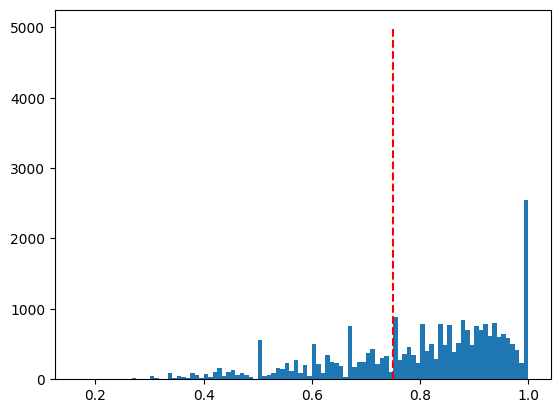

In [57]:
plt.hist(filtered.obs.top1_ratio, bins=100)
plt.vlines(0.75, ymin=0, ymax=5000, colors='r', linestyles='dashed')
plt.show()

In [58]:
filtered = filtered[filtered.obs.top1_ratio > 0.75].copy()

In [59]:
filtered.obs

,dataset,fov,cell_id,cell_type_raw,total_merfish,total_raefish,top1_id,top2_id,top1_ratio,top2_ratio,top1_rae_count,top2_rae_count,RaeFishGene
2,241018_ado,0,3,Single,1113,13,76,93,0.769231,0.076923,10,1,CRY1
8,241018_ado,0,9,Single,1040,23,76,380,0.782609,0.086957,18,2,CRY1
12,241018_ado,0,13,Single,1354,20,76,28,0.950000,0.050000,19,1,CRY1
16,241018_ado,0,17,Single,1146,23,179,354,0.913043,0.043478,21,1,HOXA3
17,241018_ado,0,18,Single,1285,31,179,73,0.870968,0.032258,27,1,HOXA3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33135,241203_kraken,189,46,Single,73,37,120,550,0.783784,0.108108,29,4,EXOSC10
33136,241203_kraken,189,47,Single,11,46,235,449,0.869565,0.043478,40,2,MED12
33137,241203_kraken,189,48,Single,31,46,550,151,0.826087,0.065217,38,3,ZNF460
33138,241203_kraken,189,49,Single,33,58,550,120,0.810345,0.034483,47,2,ZNF460


In [ ]:
filtered.write("../../datasets/raefish/raefish.h5ad")

(104, 492)


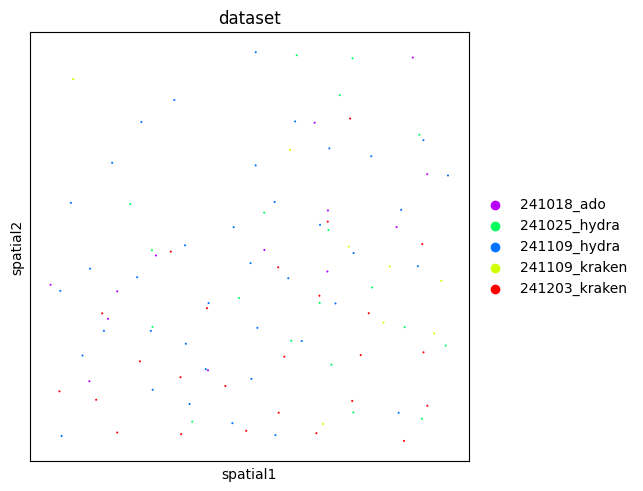

In [61]:
from matplotlib.colors import to_hex

fov = 0
dataset = '241018_ado'
plot_data = filtered[(filtered.obs.fov == fov)].copy()
print(plot_data.shape)

key = "dataset"
plot_data.obs[key] = plot_data.obs[key].astype("category").cat.remove_unused_categories()

#random shuffle
n = len(plot_data.obs[key].cat.categories)
colors = [to_hex(plt.cm.hsv(i / max(n, 1))) for i in range(n)]
np.random.default_rng(42).shuffle(colors)
plot_data.uns[f"{key}_colors"] = colors

sq.pl.spatial_scatter(
    plot_data,
    color = key,
    size=10,
    img=None,
)